# Unified MDTF/GFDL/NCAR Analysis Notebook Template

Contributors: Taydra Low, Elizabeth Maroon, Lei Huang, Yi-Hung Kuo, Stephen Yeager, Brendan Meyers, Feng Zhu, Teagan King \
Date: 07/1/26


* **Full setup instructions** (git/branch, data, configuration): see
[`natl_ocean_notebook_user_guide.md`](natl_ocean_notebook_user_guide.md). Or find the PDF version in the Google Drive: see [`Google Drive`](https://drive.google.com/drive/folders/1gNKwbffdD2m7d9Q7atEnbjG9pThvRU4i?usp=drive_link)

* View this POD development cheatsheet for additional information:
[POD development cheat sheet](https://github.com/NOAA-GFDL/MDTF-diagnostics/blob/main/doc/sphinx/dev_cheatsheet.rst)

* To run this notebook, create the `mdtf_nb` conda environment and register its kernel (only
needed once). Each POD will need esnb or intake-esm (or both if you are trying out both methods). Any additional packages are POD specific (except ipykernel and esmpy). 

* To avoid discrepancies with package dependencies, order of operations is important here. If you need to install additional packages, use conda-forge if possible. 
```bash
conda create -n mdtf_nb -c conda-forge python=3.12 xarray scipy pandas numba \
    xesmf esmpy cartopy gsw-xarray xhistogram cf_xarray matplotlib regionmask gcsfs ipykernel
conda activate mdtf_nb
pip install esnb "xwmt==0.0.3" cmip_basins intake-esm dask dask-jobqueue netcdf4 cftime
python -m ipykernel install --user --name mdtf_nb --display-name "Python (mdtf_nb)"
```

This notebook runs the `natl_ocean` POD (Maroon et al.) through the ESNB interface on CESM timeslice data.


**Kernel:** `Python (mdtf_nb)` (set via the top-right kernel selector).

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2

# cartopy gridlines(draw_labels=True) + Jupyter default bbox_inches='tight' mis-crop
# multi-panel cartopy figures to a single panel (cartopy>=0.25 / mpl>=3.11). Disable
# the tight crop so SpatialPlot_climo_bias renders both panels.
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import sys, os, copy
import json

from pathlib import Path
import xarray as xr

# Silence benign xarray warning: _FillValue/missing_value (1e+20) stored
# as both float32 and float64; both decode to NaN as intended.
import warnings
warnings.filterwarnings('ignore', message='.*multiple fill values.*', category=xr.SerializationWarning)

# ======================================================================
# USER CONFIGURATION — the single place to edit site paths for this POD.
# Everything downstream reads these via os.environ; nothing else is hardcoded.
# Set them here (CHANGE ME) or export them in your shell before launching Jupyter;
# setdefault keeps any value already exported.
# ======================================================================
os.environ.setdefault('CODE_ROOT', '/glade/work/taydral/MDTF/MDTF-diagnostics')                       # CHANGE ME: your MDTF-diagnostics repo
os.environ.setdefault('WORK_DIR',  '/glade/work/taydral/MDTF/wkdir/MDTF_output/natl_ocean')           # CHANGE ME: output / work dir
os.environ.setdefault('OBS_DATA',  '/glade/work/taydral/MDTF/inputdata/obs_data/natl_ocean')          # CHANGE ME: POD obs + benchmark reference data (obs_1x1.nc, omip*.nc, obs_wmt*.nc)
os.environ.setdefault('PBS_ACCOUNT', 'UWIS0041')                                                      # CHANGE ME: PBS account (only used if dask=True)
# Conda install root (used by MDTF 'prod' framework mode only) — derived from the active env.
os.environ.setdefault('CONDA_ROOT', os.path.dirname(os.path.dirname(os.environ.get('CONDA_EXE', sys.prefix))))

Path(os.environ['WORK_DIR']).mkdir(parents=True, exist_ok=True)

## About the POD: North Atlantic Ocean diagnostics

Authors: Elizabeth Maroon, Stephen Yeager, Taydra Low, Brenden Meyers, Feng Zhu, Teagan King

This natl_ocean POD evaluates how well climate models represent the subtropical-to-subpolar North Atlantic
ocean state, focusing on:
- Sea surface and upper-200m temperature and salinity climatologies
- Mixed layer depth (MLD)
- Potential density (σ₀)
- Surface heat and freshwater fluxes
- Surface-forced water-mass transformation (WMT) in σ₂ coordinates
- Atlantic Meridional Overturning Circulation (AMOC) streamfunction in σ₂ coordinates
- Bias relative to a 1°×1° observation-based reference (`obs_1x1.nc`)

------------------------------------------
- POD source: `diagnostics/natl_ocean/` (Maroon et al.)
- Helper module: `POD_utils.py` (bias, WMT, and AMOC analysis functions)
- Detailed description: `diagnostics/natl_ocean/doc/natl_ocean.rst`
-------------------------------------------

## Jupyter ESNB notebook POD settings
- This POD requires CMIP6 monthly ocean variables (tos, thetao, so, hfds, vsf, uo, vo) plus fx (areacello, volcello). Optional: umo, vmo for the mass-transport AMOC path.
The POD is built upon the following procedures:
### [Section 1: Prepare POD Settings](#section1)
- Set the parameters of the POD (interactive or read from `settings.jsonc`)
- Set the runtime configurations (machine, dask cluster size)
- Define the model case (CESM timeslice) and date range
- Point at the data catalog and obs / work directories
### [Section 2: Load Metadata from Catalog Files](#section2)
- Two default options available (users can override)
    -  ESNB option (current default)
    - Transition to Intake-ESM (led by Aparna)
- ESNB load for the monthly variables (auto-skips optional umo/vmo if not in catalog)
- Manual `xr.open_dataset` for fx (time-invariant) variables
- Per-variable dispatch into named datasets (`ds_thetao`, `ds_so`, `ds_uo`, `ds_vo`, …); no global merged dataset
- Detect mass-transport availability (`has_mass_transport` flag)
- Load obs
### [Section 3: Diagnostics Computation](#section3)
- Sanity check: compute σ₀ on a small slice
- Steps 1–3: bias-plot path (merge → preprocess → σ₀/MLD → zavg); regrid + climatology run behind the scenes in Section 4
- Steps 4–5: WMT path (local surface-field merge → `compute_wmt` lines + maps)
- Step 6: AMOC velocity inputs (per-variable inspection, U-vs-T grid check)
- Step 7: AMOC streamfunction in σ₂ (`POD_utils.calculate_moc` with use_currents auto/override)
### [Section 4: Results Visualization](#section4)
- Bias maps vs obs (θ, S, σ₀, MLD)
- Scatter plot of θ vs S biases
- WMT lines vs OMIP benchmarks (by region)
- Density-flux maps at specified σ₂ classes
- Atlantic AMOC(σ₂) time-mean streamfunction
- WMT + AMOC at 45°N compensation diagnostic
### [Section 5: More about this POD](#section5)
- [Check the .rst file](https://github.com/Taydra-Low/MDTF-diagnostics/blob/feature/taydra-dev/diagnostics/natl_ocean/doc/natl_ocean.rst)

<a id='section1'></a>
## Section 1: Prepare POD Settings

Load from `diagnostics/natl_ocean/settings.jsonc` (`mode == "prod"`) or define inline (`mode == "interactive"`).
We also build a monthly-only copy for ESNB — it can't time-slice the fx vars (`areacello`, `volcello`),
so we load those manually in Section 3.

**Key variables**:
- `mode`: 'interactive' (manual) or 'driver'/'prod' (framework-driven)
- `startdate`, `enddate`: analysis period
- `data_source`: **timeslice_cmorized** — the CMORized CESM timeslice bundle, loaded via ESNB (see the user guide for why this single source is used)
- `settings_*`: POD-specific options (regrid resolution, etc.)


In [2]:
# Framework: Setup paths to import MDTF code as modules
module_path = os.environ['CODE_ROOT']
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)

# Import python libraries from /src directory
from src import util              # varlist_util, translation, xr_parser, units
from src.util import json_utils

Using MDTF framework version /glade/work/taydral/MDTF/MDTF-diagnostics


 If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file.

In [3]:
# ===== USER SETTINGS — edit these =====
# Run mode: "interactive" defines settings inline (below); "prod" reads settings.jsonc
# (used when the MDTF framework drives the notebook).
mode = "interactive"

# machine / dask: whether to spin up a dask PBSCluster for parallel compute.
#   "local"  — run in-process, no dask
#   "casper" — submit a PBS job (dask-jobqueue) when dask=True
machine = "casper"      # CHANGE ME if not on Casper
dask = False            # CHANGE ME: True to enable the dask cluster (Casper)

# Verbosity
verbose = True

### Optional: spin up a dask PBSCluster on Casper

Set `machine = "casper"` in the previous cell to submit a PBS job and use `dask.distributed` for parallel compute. The cluster takes a minute or two to start (check `qstat -u $USER` from a terminal). Set `dask = False` to skip and stay single-process.

In [4]:
# Machine-specific dask setup. Casper PBS via dask-jobqueue.
client = None
cluster = None

if machine == "casper" and dask == True:
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client

    cluster = PBSCluster(
        cores=8,
        memory="32GB",
        account=os.environ['PBS_ACCOUNT'],
        interface="ext",
        job_extra_directives=[],
        walltime="4:00:00",
        queue="casper",
        resource_spec="select=1:ncpus=8:mem=32GB",
    )
    cluster.adapt(minimum_jobs=0, maximum_jobs=1)
    client = Client(cluster)
    print('dask client:', client)
    print('dashboard:', client.dashboard_link)
    # Note: cluster starts via PBS queue — `qstat -u $USER` in a terminal to monitor.
else:
    print(f'machine={machine!r} — skipping dask cluster setup')

# can also use `client = Client()` for a local cluster, but that is not recommended on Casper.

machine='casper' — skipping dask cluster setup


### POD settings are defined here (interactive mode) or read from the settings.jsonc file
- settings_dict stores the information needed to run the POD
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a settings.jsonc file
- The user can change the time period, latitude range, number of workers
- AdvUser: feel free to define own parameters

In [5]:
# ===== POD-SPECIFIC (natl_ocean): POD settings, varlist, and the ESNB monthly-only copy =====
# CESM timeslice -> data available 1995-01-01 to 2015-01-01
# We use one year's worth of data for this notebook demo
startdate, enddate = '1995-01-01', '1995-12-31'

if mode == "interactive":
    settings_full = {
        "settings": {
            # pod_options — natl_ocean-specific knobs (not read by MDTF framework)
            "pod_options": {
                "start_date":    startdate,
                "end_date":      enddate,
                # POD_utils.compute_zavg upper-ocean depth (m)
                "zavg_depth":    200,
                # POD_utils.compute_mld density threshold (kg/m^3) and reference depth (m)
                "mld_dsig":      0.03,
                "mld_rdep":      10.0,
                # POD_utils.regrid target grid (deg) and method
                "regrid_dlon":   1,
                "regrid_dlat":   1,
                "regrid_method": "bilinear",
                # POD_utils.SpatialPlot_climo_bias map region [lon_min, lon_max, lat_min, lat_max]
                "plot_region":   [270, 360, 20, 80],
                "focus_region":  [312, 330, 38, 53],
                "plot_month":    13,   # 13 = annual mean
                "num_workers":   8,
                # WMT (Section 3 Step 4+ / Section 4)
                "wmt_sigma_classes": [35.0, 36.0, 36.5],  # sigma2 levels for compute_wmt MAPS
                "wmt_dsigma":         0.1,                # sigma2 bin width
                "wmt_lat_max":        44,                 # cut to <=lat_max for SPNA WMT
            },
            "runtime_requirements": {"python3": ["matplotlib", "xarray", "xesmf"]},   # None means use the default python version of the MDTF framework
            "driver":      "natl_driver.py",
            "long_name":   "North Atlantic diagnostic in Subtropical to Subpolar latitudes",
            "convention":  "CMIP",
            "description": "North Atlantic Ocean diagnostics",
        },
        "dimensions": {
            "nlat": {"standard_name": "latitude",  "units": "degrees_north", "axis": "Y"},
            "nlon": {"standard_name": "longitude", "units": "degrees_east", "axis": "X"},
            "lev":  {"standard_name": "depth", "units": "centimeters", "axis": "Z", "positive": "down"},
            "time": {"standard_name": "time"},
        },
        "varlist": {
            "tos":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "sea_surface_temperature",                  "units": "degC"},
            "vsf":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "virtual_salt_flux_into_sea_water",         "units": "kg m-2 s-1", "requirement": "optional"},
            "wfo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "water_flux_into_sea_water",                "units": "kg m-2 s-1", "requirement": "optional"},
            "hfds":      {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "surface_downward_heat_flux_in_sea_water",  "units": "W m-2"},
            "so":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_salinity",                       "units": "psu"},
            "thetao":    {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_potential_temperature",          "units": "degC"},
            "uo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_x_velocity",                       "units": "m s-1"},
            "vo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_y_velocity",                       "units": "m s-1"},
            "umo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "ocean_mass_x_transport",                      "units": "kg s-1", "requirement": "optional"},
            "vmo":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "ocean_mass_y_transport",                      "units": "kg s-1", "requirement": "optional"},
            "volcello":  {"realm": "ocean", "dimensions": ["lev","nlat","nlon"], "standard_name": "ocean_volume", "units": "m3"},
            "areacello": {"realm": "ocean", "dimensions": ["nlat","nlon"],       "standard_name": "cell_area",    "units": "m2"},
        },
    }
else:  # prod mode: read from settings.jsonc (no pod_options block)
    settings_file_path = os.path.join(module_path, "diagnostics/natl_ocean/settings.jsonc")
    try:
        settings_full = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# POD-specific: build a monthly-only varlist for ESNB (settings_monthly).
# ESNB time-slices EVERY variable in the varlist when it opens the data, but the fx
# (time-invariant) vars areacello/volcello have no time dimension — leaving them in
# the varlist makes ESNB's .open() fail. So hand ESNB a copy with the fx vars removed
# (below), then load areacello/volcello manually in the fx cell in Section 2.
# settings_full keeps the complete varlist for reference.
settings_monthly = copy.deepcopy(settings_full)
for fx_var in ('areacello', 'volcello'):
    settings_monthly['varlist'].pop(fx_var, None)

# Pre-filter optional vars: ESNB doesn't gracefully skip missing optional vars
# at .open() time — it raises "OSError: no files to open" when no catalog rows
# match. Inspect the catalog and drop any varlist entries marked
# "requirement": "optional" that aren't present. Lets the notebook run on
# models that lack umo/vmo (e.g., CESM timeslice) without changing the
# settings declaration.
import pandas as pd
# Catalog for the CMORized timeslice (lives in the POD dir).
_catalog_name = "CESM_timeslice_cmorized_001.json"
_catalog_json_path = Path(module_path) / "diagnostics/natl_ocean" / _catalog_name
with open(_catalog_json_path) as _f:
    _catmeta = json.load(_f)
# catalog_file in the JSON metadata may be a file:// URL or a bare relative
# filename (CESM timeslice catalog) — strip the prefix and resolve against the JSON dir.
_csv_path = _catmeta['catalog_file']
if _csv_path.startswith('file://'):
    _csv_path = _csv_path[len('file://'):]
if not os.path.isabs(_csv_path):
    _csv_path = str(_catalog_json_path.parent / _csv_path)
_available_vars = set(pd.read_csv(_csv_path)['variable_id'])
for _var, _entry in list(settings_monthly['varlist'].items()):
    if _entry.get('requirement') == 'optional' and _var not in _available_vars:
        settings_monthly['varlist'].pop(_var)
        print(f'Dropped optional var {_var!r} from ESNB load — not in catalog')

print('varlist (ESNB):', list(settings_monthly['varlist'].keys()))
print('varlist (full):', list(settings_full['varlist'].keys()))

Dropped optional var 'vsf' from ESNB load — not in catalog
Dropped optional var 'umo' from ESNB load — not in catalog
Dropped optional var 'vmo' from ESNB load — not in catalog
varlist (ESNB): ['tos', 'wfo', 'hfds', 'so', 'thetao', 'uo', 'vo']
varlist (full): ['tos', 'vsf', 'wfo', 'hfds', 'so', 'thetao', 'uo', 'vo', 'umo', 'vmo', 'volcello', 'areacello']


### The runtime configuration is defined here (interactive mode) or read from the runtime_config.yml file

Defines which simulation(s) to pull from the catalog, the date range, and output paths.

- If running in interactive mode, case settings are entered inline below.
- Otherwise they can be read from a `runtime_config.yml`-style file (not used here).

In [6]:
if mode == "interactive":
    # CMORized CESM timeslice catalog + case label.
    _catalog   = "CESM_timeslice_cmorized_001.json"
    _case_name = "CESM-mdtfv3-timeslice-cmorized_r1i1p1f1"

    case_info = {
        "case_list": {
            _case_name: {
                "model": "CESM", "convention": "CMIP",
                "startdate": startdate, "enddate": enddate,
            }
        },
        "DATA_CATALOG":   str(Path(module_path) / "diagnostics/natl_ocean" / _catalog),
        "OBS_DATA_ROOT":  str(Path(os.environ["OBS_DATA"]).parent),
        "WORK_DIR":       os.environ["WORK_DIR"],
        "OUTPUT_DIR":     os.environ["WORK_DIR"],
        "conda_root":     os.environ["CONDA_ROOT"],
        "conda_env_root": os.path.join(os.environ["CONDA_ROOT"], "envs"),
        "micromamba_exe": "", 
        "large_file": False,
        "make_multicase_figure_html": False, 
        "make_variab_tar": False,
        "overwrite": True, 
        "pod_list": ["natl_ocean"],
        "run_pp": True, 
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True, 
        "user_pp_scripts": [""],
    }
else:
    # natl_ocean doesn't ship a runtime_config.yml; if you wire one up, load it here.
    case_input_file = os.path.join(module_path, "runtime_config_casper.jsonc")
    print(f"Reading case info from {case_input_file}")
    case_info = json_utils.read_json(case_input_file)

print("Data source: CESM timeslice")
print(f"Catalog: {case_info['DATA_CATALOG']} (exists: {Path(case_info['DATA_CATALOG']).exists()})")


Data source: CESM timeslice
Catalog: /glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/CESM_timeslice_cmorized_001.json (exists: True)


<a id='section2'></a>
## Section 2: Load Metadata from Catalog files

This section uses the ESNB library (Enhanced Jupyter Notebook-based framework) to load data from intake-esm catalogs.

**What happens here**:
1. ESNB opens the intake-esm catalog (JSON file)
2. Queries for required variables (thetao, so, uo, vo, etc.)
3. Loads NetCDF files into xarray Datasets
4. Handles optional variables gracefully

**Note**: When running via the MDTF framework, this section is skipped. The framework handles preprocessing instead and provides preprocessed data to the POD driver.

**CESM timeslice**: this notebook loads the **CMORized** timeslice bundle (CMIP-named NetCDF), so ESNB opens it directly like any CMIP model.


**NOTE**: The ESNB library and its functions are only used in this section. Currently only two functions are needed for this POD: `NotebookDiagnostic` and `CaseGroup2`. Users also have the option to use [intake-ESM](https://intake-esm.readthedocs.io/en/stable/) functions (example of this is in a different notebook).


In [7]:
# Import ESNB library and necessary functions
import esnb
from esnb import NotebookDiagnostic, CaseGroup2

### Initialize the diagnostic and an MDTF case

In [8]:
# ---- Load per-variable datasets (Section 2 core) ----
# Load the CMORized timeslice THROUGH ESNB (NotebookDiagnostic -> CaseGroup2 -> resolve
# -> open). CMORized files carry CMIP names, so ESNB opens them like any CMIP model.
# Produces `loaded_datasets`: single-variable datasets the dispatch cell consumes.
_pod_dir = Path(module_path) / 'diagnostics/natl_ocean'
if str(_pod_dir) not in sys.path:
    sys.path.append(str(_pod_dir))
import POD_utils

pod_env_vars = NotebookDiagnostic(settings_monthly)
groups = [CaseGroup2(case_info, date_range=(startdate, enddate))]
pod_env_vars.resolve(groups)
print('Files to load (via ESNB):')
for _f in pod_env_vars.files:
    print('   ', _f)
pod_env_vars.open()
loaded_datasets = list(pod_env_vars.datasets)
print(f'ESNB loaded {len(loaded_datasets)} CMORized variables: '
      f'{[list(d.data_vars)[0] for d in loaded_datasets]}')

Files to load (via ESNB):
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/hfds_Omon_CESM-mdtfv3-timeslice_timeslice_r1i1p1f1_gn_199501-199512.nc
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/so_Omon_CESM-mdtfv3-timeslice_timeslice_r1i1p1f1_gn_199501-199512.nc
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/thetao_Omon_CESM-mdtfv3-timeslice_timeslice_r1i1p1f1_gn_199501-199512.nc
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/tos_Omon_CESM-mdtfv3-timeslice_timeslice_r1i1p1f1_gn_199501-199512.nc
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/uo_Omon_CESM-mdtfv3-timeslice_timeslice_r1i1p1f1_gn_199501-199512.nc
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/vo_Omon_CESM-mdtfv3-timeslice_timeslice_r1i1p1f1_gn_199501-199512.nc
    /glade/work/taydral/MDTF/inputdata/cesm_mdtfv3_timeslice_cmorized_1yr/wfo_Omon_CESM-mdtfv3-timeslice_time

### POD-specific: load fx variables and bind all loaded variables

ESNB's `.open()` time-slices every dataset by `date_range`, which errors on `areacello` and `volcello` (no time dim), so we open those directly with `xr.open_dataset`. The cell below then binds **every** loaded variable — the fx vars plus the ESNB-loaded tracers/velocities — into named per-variable datasets (kept separate, not merged, so the T-grid tracers and U-grid velocities don't collide).

In [9]:
# ===== POD-SPECIFIC (natl_ocean): manual fx load + per-variable dispatch of the ESNB-loaded datasets =====

# fx (time-invariant) vars: areacello (cell area) and volcello (cell volume).
# ESNB time-slices every loaded variable, but fx have no time dim, so they are
# loaded manually here. The CMORized bundle ships its fx inside the catalog, so
# read their paths from it — the bundle is self-contained (no FX_DIR needed).
_fxmeta = json.load(open(case_info['DATA_CATALOG']))
_fxdf = pd.read_csv(_fxmeta['catalog_file'])
_fxp = {v: _fxdf.loc[_fxdf.variable_id == v, 'path'].iloc[0] for v in ('areacello', 'volcello')}
ds_areacello = xr.open_dataset(_fxp['areacello'])
ds_volcello  = xr.open_dataset(_fxp['volcello'])

# Per-variable dispatch: keep each ESNB-loaded variable in its own xarray.Dataset
# instead of merging into one. This is required for downstream AMOC code
# (Sub2Sub's calculate_moc takes separate ds_t, ds_u, ds_v inputs), and avoids
# the T-grid / U-grid coord-conflict that an xr.merge of tracers + velocities
# would produce.
ds_by_var = {}
for ds in loaded_datasets:
    # Each ESNB-returned dataset wraps exactly one main variable. Find which
    # one and stash the dataset under that name. Order in the tuple is
    # arbitrary — break on the first match per dataset.
    for v in ('thetao', 'so', 'uo', 'vo', 'umo', 'vmo', 'tos', 'hfds', 'vsf', 'wfo'):
        if v in ds.data_vars:
            ds_by_var[v] = ds
            break

# Required variables — fail loudly if any are missing from the ESNB load
ds_thetao = ds_by_var['thetao']   # T-grid 4D (time, lev, nlat, nlon), degC
ds_so     = ds_by_var['so']       # T-grid 4D, psu
ds_uo     = ds_by_var['uo']       # U-grid 4D, m s-1
ds_vo     = ds_by_var['vo']       # U-grid 4D, m s-1
ds_tos    = ds_by_var['tos']      # T-grid 3D surface (time, nlat, nlon)
ds_hfds   = ds_by_var['hfds']     # T-grid 3D surface, W m-2
# Surface freshwater forcing: CESM has vsf (virtual salt flux); most CMIP models
# have wfo (freshwater flux). Load whichever is present (at least one required);
# prefer wfo when both exist. ds_fwflux is the single handle used downstream.
ds_vsf    = ds_by_var.get('vsf')  # T-grid 3D surface, kg m-2 s-1 (CESM); else None
ds_wfo    = ds_by_var.get('wfo')  # T-grid 3D surface, kg m-2 s-1 (CMIP);  else None
if ds_vsf is None and ds_wfo is None:
    raise KeyError('Need vsf or wfo for the WMT freshwater forcing; loaded neither')
ds_fwflux  = ds_wfo if ds_wfo is not None else ds_vsf
fwflux_var = 'wfo' if ds_wfo is not None else 'vsf'

# Optional variables — None if the model doesn't output mass transport
# (e.g., CESM only has uo/vo). The AMOC code will fall back to
# velocity inputs in that case.
ds_umo    = ds_by_var.get('umo')
ds_vmo    = ds_by_var.get('vmo')

# Detect mass-transport availability — this flag drives the branch in the
# AMOC integration (use_currents=True with uo/vo, False with umo/vmo).
has_mass_transport = ds_umo is not None and ds_vmo is not None
if has_mass_transport:
    print('umo/vmo available — AMOC code can use mass-transport inputs (use_currents=False)')
else:
    print('umo/vmo NOT available — AMOC code will fall back to uo/vo velocity (use_currents=True)')

# Inventory print for sanity — all variables now loaded
print(f'  loaded tracers:   thetao, so, tos, hfds, {fwflux_var}')
print(f'  loaded velocity:  uo, vo')
print(f'  loaded mass-tpt:  {"umo, vmo" if has_mass_transport else "(none)"}')
print(f'  loaded fx:        areacello, volcello')

umo/vmo NOT available — AMOC code will fall back to uo/vo velocity (use_currents=True)
  loaded tracers:   thetao, so, tos, hfds, wfo
  loaded velocity:  uo, vo
  loaded mass-tpt:  (none)
  loaded fx:        areacello, volcello


### Open the comparison data (observations + OMIP)

Load both benchmarks the Section 4 bias maps and scatter plots use: the gridded observations (`obs_1x1.nc`) and the OMIP model comparison (`omip2.cycle1.1989_2018.0-200m…nc`, `OMIP=0` to match the driver). All comparison-data reads are kept here in Section 2, next to the model load.

In [10]:
# Observational reference (gridded obs) — the bias-map benchmark used in Section 4.
ds_obs = xr.open_dataset(os.path.join(os.environ['OBS_DATA'], 'obs_1x1.nc')).load()
print(f'obs vars: {list(ds_obs.data_vars)}')
print(f'obs dims: {dict(ds_obs.sizes)}')

# OMIP model comparison — used alongside obs in the Section 4 bias maps + scatter.
# Select OMIP=0 (first iteration) to match the driver.
_omip_file = os.path.join(os.environ['OBS_DATA'], 'omip2.cycle1.1989_2018.0-200m.mld_sic_t_s_sigma.nc')
ds_model = xr.open_dataset(_omip_file).isel(OMIP=0).load()
print(f'OMIP vars: {list(ds_model.data_vars)}')
print(f'OMIP dims: {dict(ds_model.sizes)}')

obs vars: ['thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic', 'mld']
obs dims: {'month': 12, 'lat': 180, 'lon': 360}
OMIP vars: ['mld', 'thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic']
OMIP dims: {'month': 12, 'model': 16, 'lat': 180, 'lon': 360}


<a id='section3'></a>
## Section 3: Diagnostics Computation (7 Steps)

**POD-specific logic**: This section contains all the physics calculations specific to the natl_ocean POD. The logic is independent of the data source — the same steps work for CESM timeslice or any model, provided inputs are preprocessed coordinates and 3D fields.

Mirrors `diagnostics/natl_ocean/natl_driver.py` Parts 1–3, plus the AMOC code. Each step calls a function in `POD_utils.py` (imported in Section 2) using values from the `pod_options` block defined in Section 1.

**Workflow**:
- **Step 1**: Preprocess coordinates → standardize dimension names
- **Step 2**: Compute σ₀ (potential density) and MLD (mixed layer depth)
- **Step 3**: Depth-average T, S, σ₀ over the upper 200m
- **Step 4**: Prepare surface fluxes for WMT forcing
- **Step 5**: Water Mass Transformation (WMT) in σ₂ coordinates
- **Step 6**: Prepare velocity fields for AMOC
- **Step 7**: AMOC streamfunction in σ₂ coordinates

Regridding to a regular 1°×1° lat-lon grid and the monthly climatology run behind the scenes via `POD_utils.regrid_and_climatology`, called in Section 4 just before the bias maps.

These map to three paths: **Steps 1–3** bias path, **Steps 4–5** WMT path, **Steps 6–7** AMOC path.


In [11]:
pod_dir = Path(module_path) / 'diagnostics/natl_ocean'
if str(pod_dir) not in sys.path:
    sys.path.append(str(pod_dir))

import POD_utils

# Shortcut for the natl_ocean knobs defined in Section 1
opts = settings_full['settings']['pod_options']
print('pod_options keys:', list(opts.keys()))

pod_options keys: ['start_date', 'end_date', 'zavg_depth', 'mld_dsig', 'mld_rdep', 'regrid_dlon', 'regrid_dlat', 'regrid_method', 'plot_region', 'focus_region', 'plot_month', 'num_workers', 'wmt_sigma_classes', 'wmt_dsigma', 'wmt_lat_max']


### Step 1: Preprocess coords + compute layer thickness `dz`

Handled by `POD_utils.preprocess_bias_inputs`, which merges the tracers + fx, runs `preprocess_coords`, and returns the bias-path `ds_target` plus the per-cell thickness `dz = volcello / areacello` (`lev` converted cm→m so `compute_zavg` can subset by depth in meters).

In [12]:
# Local merge for the bias path: combine the T-grid tracers + fx vars into a
# single dataset that POD_utils.preprocess_coords and the downstream zavg/regrid
# functions expect. Per-variable datasets are kept globally; this merge is
# scoped to the bias section. Velocity vars (uo/vo, U-grid) are excluded —
# they would conflict on lat/lon coord values.
ds_bias = xr.merge(
    [ds_thetao, ds_so, ds_hfds, ds_fwflux, ds_tos, ds_areacello, ds_volcello],
    join='outer',
)

# preprocess_coords renames POP-style dim names (nlat/nlon -> y/x, etc.) and
# converts depth units. Unify chunks before rechunk so xr.apply_ufunc (used by
# compute_sigma0/compute_mld below) sees consistent dask chunks.
ds_target = POD_utils.preprocess_coords(ds_bias)
ds_target = ds_target.unify_chunks().chunk({'lev': -1})

# dz = per-cell layer thickness, derived from volcello (cell volume) / areacello
# (cell area). Built directly from the per-variable fx datasets — no need to
# go through ds_bias.
dz = ds_volcello['volcello'] / ds_areacello['areacello']
if 'lev' not in dz.coords:
    dz = dz.assign_coords(lev=ds_volcello['lev'])
# CESM POP fx report lev in cm; convert to m so compute_zavg can subset by depth
# in meters. Guard on the values (convert only when still in cm) so it is robust
# across sources.
if float(dz.lev.max()) > 8000:
    dz = dz.assign_coords(lev=dz.lev / 100.0)

print('dz dims:', dict(dz.sizes))
print('ds_target dims:', dict(ds_target.sizes))

dz dims: {'lev': 60, 'nlat': 384, 'nlon': 320}
ds_target dims: {'time': 12, 'y': 384, 'x': 320, 'lev': 120, 'vertices': 4, 'bnds': 2}


### Step 2: Compute σ₀ and MLD

Uses `pod_options.mld_dsig` (density threshold) and `pod_options.mld_rdep` (reference depth).

In [13]:
# Step 2: Compute potential density (σ₀) and mixed layer depth (MLD)
ds_target['sigma0'] = POD_utils.compute_sigma0(ds_target['thetao'], ds_target['so'])
ds_target['mld']    = POD_utils.compute_mld(ds_target['sigma0'], dsig=opts['mld_dsig'], rdep=opts['mld_rdep'])

print(f"sigma0 mean: {float(ds_target.sigma0.mean()):.3f} kg/m^3")
print(f"mld mean:    {float(ds_target.mld.mean()):.3f} m")

sigma0 mean: 26.261 kg/m^3
mld mean:    12.428 m


### Step 3: Upper-200m thickness-weighted means of θ, S, σ₀

Calls `POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])` for each var, then drops the full-depth 3D fields so `regrid` doesn't have to ship the heavy 4D arrays.

In [14]:
# Step 3: Compute thickness-weighted (zavg) means of T, S, σ₀ in upper 200m
zavg_vars = ['thetao', 'so', 'sigma0']
for var in zavg_vars:
    ds_target = POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])
ds_target = ds_target.drop_vars(zavg_vars)

print('after zavg, vars:', sorted(list(ds_target.data_vars)))

after zavg, vars: ['areacello', 'hfds', 'lat_bnds', 'lev_bnds', 'lon_bnds', 'mld', 'sigma0_zavg', 'so_zavg', 'thetao_zavg', 'tos', 'volcello', 'wfo']


### Step 4: Regrid to lat-lon

Uses `pod_options.regrid_dlon`, `regrid_dlat`, and `regrid_method` (default 1°×1° bilinear).

In [15]:
# Step 4: Regrid to regular 1°×1° lat-lon grid for comparison with observations
ds_target = POD_utils.regrid(
    ds_target,
    dlon=opts['regrid_dlon'],
    dlat=opts['regrid_dlat'],
    method=opts['regrid_method'],
)
print('after regrid, dims:', dict(ds_target.sizes))

after regrid, dims: {'time': 12, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 120}


### Step 5: Monthly climatology + tag with model name

Collapses the time axis to a 12-month climatology and adds a `model` scalar coordinate so downstream plots can label the data.

In [16]:
model_name = next(iter(case_info['case_list']))
ds_target = ds_target.groupby('time.month').mean('time', keep_attrs=True)
ds_target = ds_target.assign_coords({'model': model_name})

# Materialize into memory: the climatology is small (12 months x 180 x 360),
# and POD_utils.SpatialPlot_climo_bias calls xr.apply_ufunc without dask support.
ds_target = ds_target.load()

print('climatology dims:', dict(ds_target.sizes))
print('model_name:', model_name)

climatology dims: {'month': 12, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 120}
model_name: CESM-mdtfv3-timeslice-cmorized_r1i1p1f1


### Step 6: Prepare surface fields for WMT (Surface-Forced Water Mass Transformation)

Mirrors `natl_driver.py:280-298`. WMT requires a different chunking and surface-only fields, so we build a fresh `ds_target_wmt` via a local merge of the per-variable T-grid datasets (`ds_tos`, `ds_hfds`, `ds_vsf`, `ds_areacello`, plus surface `so`) rather than reusing `ds_target` from the bias-plot path. Region is cut to lat ≤ `pod_options.wmt_lat_max` for compute efficiency.

In [17]:
import numpy as np

# Local merge for the WMT path: only the surface T-grid vars xwmt needs
# (surface temp, surface heat flux, virtual salt flux, cell area). Per-variable
# isolation pattern means we explicitly pick the [[var]] subset from each
# dataset rather than slicing a pre-merged ds_merged.
ds_target_wmt = xr.merge(
    [ds_tos[['tos']], ds_hfds[['hfds']], ds_fwflux[[fwflux_var]], ds_areacello[['areacello']]],
    join='outer',
).copy()

# Surface salinity: take the top model level of so and drop the lev coord so
# the result lives on the same 2D (time, nlat, nlon) grid as the other WMT
# inputs. xwmt expects sos as a surface variable.
ds_target_wmt['sos'] = ds_so['so'].isel(lev=0).drop_vars('lev')

# Rename POP-style dim names to xwmt's expected y/x
ds_target_wmt = ds_target_wmt.rename({'nlat': 'y', 'nlon': 'x'})

# Restrict to subpolar latitudes (lat <= wmt_lat_max). Mirrors the driver's
# y-slice trick: find the max y-index where lat < threshold across all x, then
# slice [miny:maxy]. Cuts the array down for compute efficiency since WMT
# only cares about the SPNA region.
miny = ds_target_wmt['y'].where(ds_target_wmt['lat'] < opts['wmt_lat_max']).max('y').min('x')
maxy = ds_target_wmt['y'].max('y')
ds_target_wmt = ds_target_wmt.sel(y=slice(miny, maxy))

# Rechunk for xwmt.swmt: x/y as single chunks, time as per-step chunks (one
# month per chunk). The xwmt loop iterates over time, so per-step chunks let
# dask parallelize across timesteps.
ds_target_wmt = ds_target_wmt.unify_chunks().chunk({'y': -1, 'x': -1, 'time': 1})
print('ds_target_wmt vars:', list(ds_target_wmt.data_vars))
print('ds_target_wmt dims:', dict(ds_target_wmt.sizes))

ds_target_wmt vars: ['tos', 'hfds', 'wfo', 'areacello', 'sos']
ds_target_wmt dims: {'time': 12, 'y': 90, 'x': 320}


### Step 7: Compute WMT in σ₂ coordinates

Two calls to `POD_utils.compute_wmt` — one for lines (sum over region, mean over time) and one for maps at the σ₂ classes set in `pod_options.wmt_sigma_classes`.

In [18]:
# Step 7: Compute WMT in sigma2 — WMT-vs-density lines (by region) + surface density-flux MAPS
sigma_classes = np.array(opts['wmt_sigma_classes'])
dsigma = opts['wmt_dsigma']

# Lines: WMT vs sigma2, summed over each SPNA region, time-averaged
ds_wmt_lines = POD_utils.compute_wmt(ds_target_wmt, 'WMT', 'sigma2', dsigma)
ds_wmt_lines = ds_wmt_lines.mean('time')

# Maps: surface density flux at each sigma class
ds_wmt_maps = POD_utils.compute_wmt(
    ds_target_wmt, 'MAPS', 'sigma2', dsigma,
    dclasses=sigma_classes,
)

# Regrid the model maps from the native curvilinear grid onto a regular 1deg x 1deg
# lat-lon grid (POD_utils.regrid defaults to a 1x1 global grid) so they sit on the
# same grid as the 1x1 obs benchmark before plotting. compute_wmt returns a
# DataArray, so wrap/unwrap through a Dataset for the regridder.
ds_wmt_maps = POD_utils.regrid(ds_wmt_maps.to_dataset(name='wmt'))['wmt']

[35.  36.  36.5] 3


### Step 8: AMOC velocity inputs (U-grid)

Inspect the per-variable velocity datasets that the upcoming AMOC code will consume. `calculate_moc(ds_t, ds_u, ds_v, use_currents=...)` takes its u and v inputs as separate single-variable datasets that might be on different grids, so we do **not** merge them here.

`uo`/`vo` live on POP's staggered U-grid (ULAT/ULONG) and the tracers live on the T-grid (TLAT/TLONG); the two share `nlat`/`nlon` index dims but have different `lat`/`lon` coordinate values (~0.27° offset). Keeping them in separate datasets avoids the merge conflict and matches the AMOC code's expected interface. Functionality for other Arakawa grids is in POD_utils.py. Arakawa grid automatically determined.

If `has_mass_transport` (set in cell 30) is True, `ds_umo`/`ds_vmo` will be wired in with `use_currents=False`; otherwise `ds_uo`/`ds_vo` with `use_currents=True`.

In [19]:
# Step 8: Inspect the per-variable velocity datasets that will feed AMOC.
# calculate_moc(ds_t, ds_u, ds_v, use_currents=...) consumes ds_u and ds_v as
# separate single-variable datasets, so we don't merge them here. The
# has_mass_transport flag from the dispatch cell decides whether ds_uo/ds_vo or
# ds_umo/ds_vmo will be wired in when the AMOC code lands.

# Velocity datasets — always loaded
print('Velocity datasets (always loaded):')
for name, ds in [('uo', ds_uo), ('vo', ds_vo)]:
    da = ds[name]
    print(f'  ds_{name}.{name}: dims={dict(da.sizes)} units={da.attrs.get("units")}')

# Mass-transport datasets — only loaded if the model outputs them
if has_mass_transport:
    print('Mass-transport datasets (optional, available here):')
    for name, ds in [('umo', ds_umo), ('vmo', ds_vmo)]:
        da = ds[name]
        print(f'  ds_{name}.{name}: dims={dict(da.sizes)} units={da.attrs.get("units")}')
else:
    print('Mass-transport datasets: (not available for this model)')

# Grid sanity check: confirm uo lives on POP's U-grid (ULAT/ULONG, cell corners)
# while thetao lives on the T-grid (TLAT/TLONG, cell centers). The two share
# the nlat/nlon index dims (384x320) but have different lat/lon coordinate
# values — verified offset is ~0.27°. This is the reason we keep them in
# separate datasets rather than merging.
ugrid_lat = ds_uo['lat'].values[0, 0]
tgrid_lat = ds_thetao['lat'].values[0, 0]
print(f'\nU-grid lat[0,0]={ugrid_lat:.3f}  vs  T-grid lat[0,0]={tgrid_lat:.3f} '
      f'(diff {ugrid_lat - tgrid_lat:+.3f}°)')

Velocity datasets (always loaded):
  ds_uo.uo: dims={'time': 12, 'lev': 60, 'nlat': 384, 'nlon': 320} units=m s-1
  ds_vo.vo: dims={'time': 12, 'lev': 60, 'nlat': 384, 'nlon': 320} units=m s-1
Mass-transport datasets: (not available for this model)

U-grid lat[0,0]=-78.953  vs  T-grid lat[0,0]=-79.221 (diff +0.268°)


### Step 9: Compute AMOC streamfunction in σ₂ coordinates

Build the three datasets `POD_utils.calculate_moc` consumes:

- `ds_t` — merged tracers (thetao, so) + lev_bnds + time_bnds, on the T-grid
- `ds_u` — either `ds_uo` or `ds_umo` (decided by `has_mass_transport` from cell 30)
- `ds_v` — either `ds_vo` or `ds_vmo`

Each goes through `POD_utils.preprocess_coords` to get y/x dim names and meter depth units. The if-check on `has_mass_transport` sets `use_currents` (True → velocity uo/vo path; False → mass-transport umo/vmo path). The `force_use_currents` override lets you force either path explicitly — useful for comparing the two on a model that outputs both.

`calculate_moc` does the heavy lifting: σ₂ binning of velocities/fluxes, w-flux convergence in σ-space, basin masking via `cmip_basins`, zonal sum + meridional cumulative integral → MOC(region, σ, lat, time) in Sv. The Atlantic southern boundary correction is applied internally.

In [20]:
# Step 9: Compute AMOC streamfunction in sigma2 coordinates.
# calculate_moc expects three datasets with y/x dim names and lev in meters,
# so run each through POD_utils.preprocess_coords first.

# Optional override: set to True to force velocity (uo/vo) path even when
# umo/vmo are available; False to require mass-transport (errors if umo/vmo
# missing); None to auto-pick based on has_mass_transport from the dispatch cell.
# Useful for comparing both paths on a model that outputs both.
force_use_currents = None

# Decide which path to use: None = auto-pick from has_mass_transport
if force_use_currents is None:
    use_currents = not has_mass_transport
else:
    use_currents = bool(force_use_currents)

# Validate: mass-transport path requires umo/vmo to be loaded
if not use_currents and not has_mass_transport:
    raise RuntimeError(
        'Cannot use mass-transport path: umo/vmo not loaded for this model. '
        'Set force_use_currents=True to use uo/vo instead.'
    )

# Build the three datasets calculate_moc consumes
# Tracer dataset: thetao + so + lev_bnds + time_bnds, all on T-grid. The
# function reads ds_t['thetao'], ds_t['so'], ds_t['lev_bnds'], ds_t['time_bnds']
# internally.
ds_t_for_amoc = POD_utils.preprocess_coords(
    xr.merge([ds_thetao, ds_so], join='outer')
)

# reset_coords(drop=True) strips dz's lon/lat so they don't collide with the
# U-grid coords on multiply; pin lev to the tracer grid to avoid float-label drift.
_dz3d = dz.rename({'nlat': 'y', 'nlon': 'x'}).reset_coords(drop=True)
_dz3d = _dz3d.assign_coords(lev=ds_t_for_amoc['lev'])
ds_t_for_amoc['dz'] = _dz3d


# Velocity datasets: pick mass-transport (umo/vmo) or velocity (uo/vo) per
# use_currents flag above. Both are supported — calculate_moc switches
# internally on the use_currents arg.
if use_currents:
    print('AMOC: using uo/vo (velocity) — use_currents=True')
    ds_u_for_amoc = POD_utils.preprocess_coords(ds_uo)
    ds_v_for_amoc = POD_utils.preprocess_coords(ds_vo)
else:
    print('AMOC: using umo/vmo (mass transport) — use_currents=False')
    ds_u_for_amoc = POD_utils.preprocess_coords(ds_umo)
    ds_v_for_amoc = POD_utils.preprocess_coords(ds_vmo)

# Compute MOC. Returns Dataset with MOC(region=3, lat, sigma, time) in Sv.
# region 0=Global, 1=Atlantic+Arctic, 2=IndoPac+SO. May take several minutes
# on 30 yrs depending on dask worker count.
ds_moc = POD_utils.calculate_moc(
    ds_t_for_amoc, ds_u_for_amoc, ds_v_for_amoc, use_currents=use_currents,
)
print('ds_moc dims:', dict(ds_moc.sizes))
print('regions:', ds_moc.region.values.tolist() if 'region' in ds_moc.coords else '(unlabeled)')
print('sigma range:', float(ds_moc.sigma.min()), '->', float(ds_moc.sigma.max()), 'kg/m^3')

AMOC: using uo/vo (velocity) — use_currents=True
AMOC: detected 'b'-grid


ds_moc dims: {'sigma': 96, 'lat': 179, 'region': 3, 'time': 12}
regions: (unlabeled)
sigma range: 0.0 -> 37.97499999999989 kg/m^3


<a id='section4'></a>
## Section 4: Results Visualization

Generate diagnostic figures comparing model output against observations and benchmarks.

- **Bias plots**: model (`ds_target`) vs OMIP (`ds_model`) vs obs (`ds_obs`) — θ, S, σ₀, MLD maps and θ/S scatter
- **WMT plots**: model (`ds_wmt_lines`, `ds_wmt_maps`) vs observation-based benchmarks (by region and at σ₂ classes)
- **AMOC plot**: Atlantic basin streamfunction (`ds_moc`) in σ₂ coordinates, time mean
- **WMT + AMOC@45°N**: compensation diagnostic in σ₂ space (obs WMT + model WMT + model AMOC@45°N)

**Output**: PNG files saved to the current directory (or `$WORK_DIR` when run by the MDTF framework).


### Bias maps vs obs (θ, S, σ₀, MLD)

Each call to `POD_utils.SpatialPlot_climo_bias` produces a two-panel bias map for one variable. Returned datasets `ds_t200` and `ds_s200` hold the θ and S bias fields used by the scatter plot below.

<xarray.Dataset> Size: 4kB
Dimensions:   (lon: 90, lat: 60, model: 17)
Coordinates:
  * lon       (lon) float64 720B 270.5 271.5 272.5 273.5 ... 357.5 358.5 359.5
  * lat       (lat) float64 480B 20.5 21.5 22.5 23.5 ... 76.5 77.5 78.5 79.5
  * model     (model) <U39 3kB 'TaiESM1-TIMCOM' ... 'CESM-mdtfv3-timeslice-cm...
    cycle     int64 8B 1
    OMIP      <U1 4B '2'
Data variables:
    mld_bias  (model) float64 136B -35.67 -16.5 -12.34 ... -20.67 -20.21 -54.75
    mld_rmse  (model) float64 136B 36.92 31.81 50.63 143.5 ... 31.27 46.67 64.33

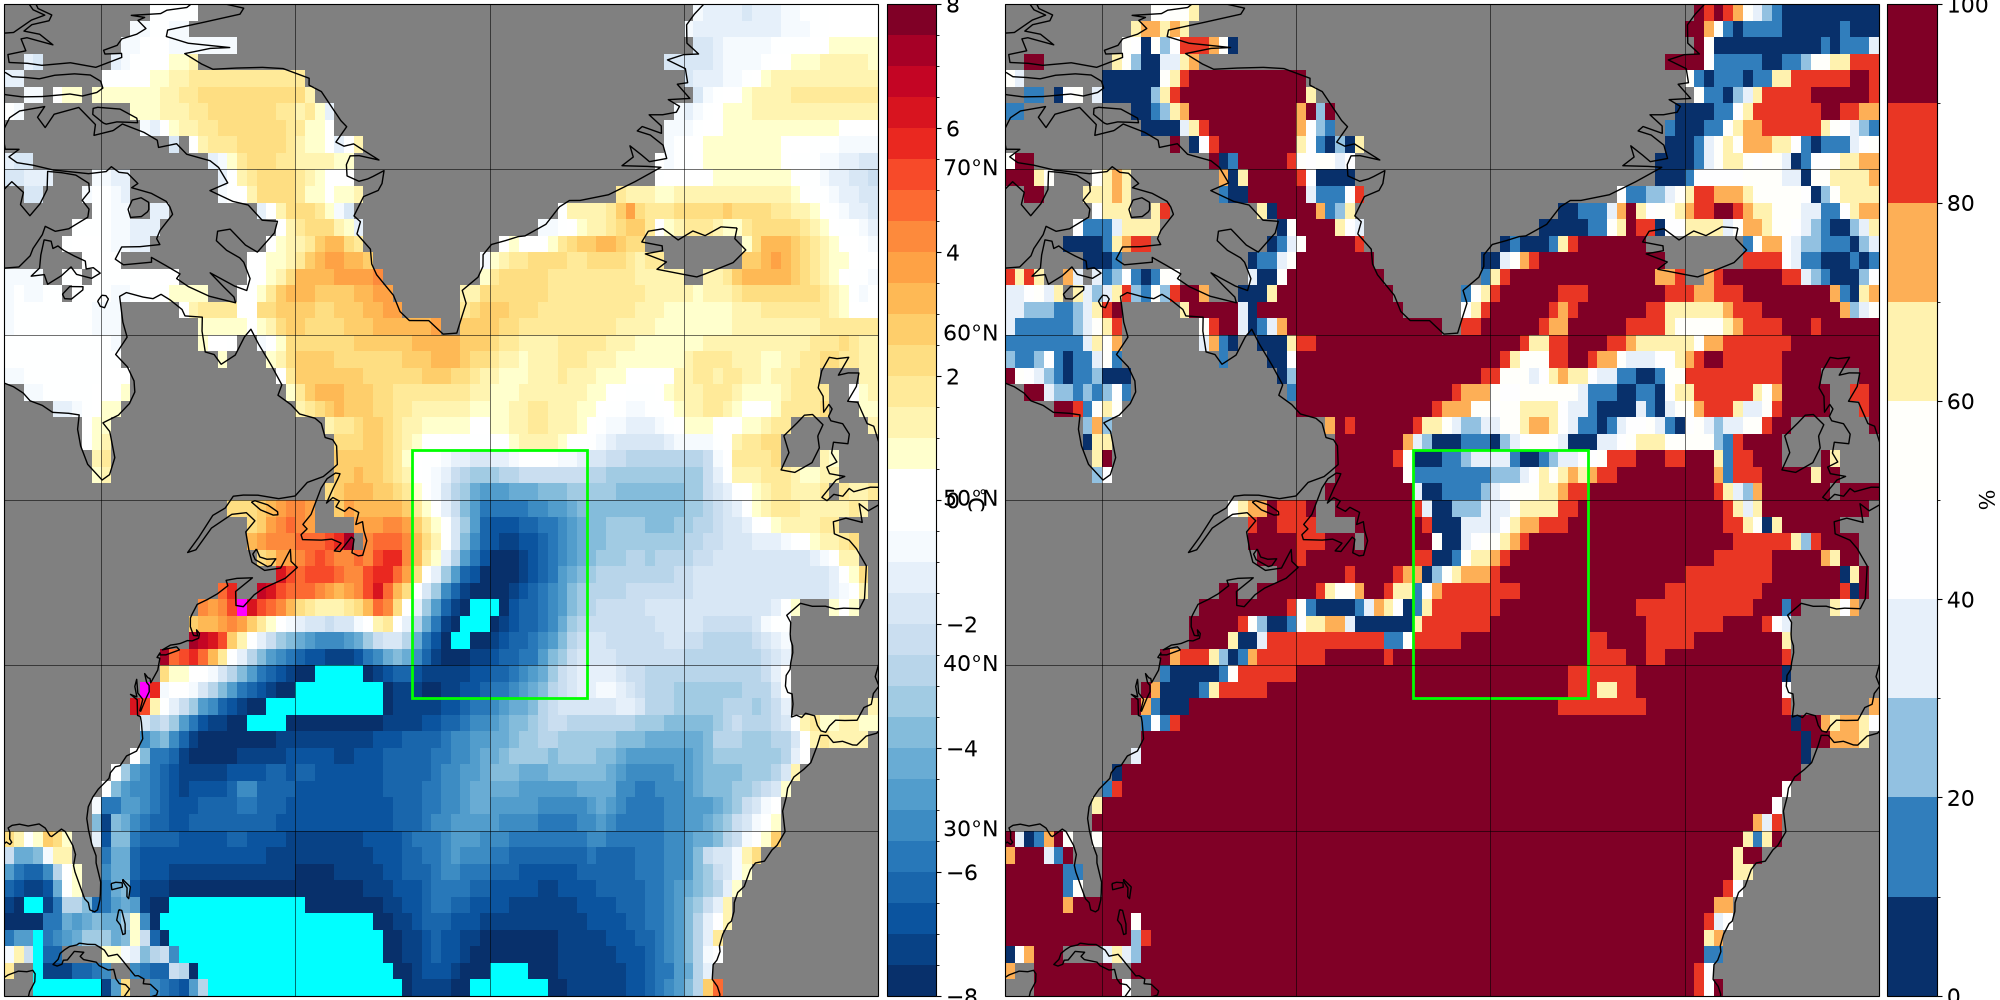

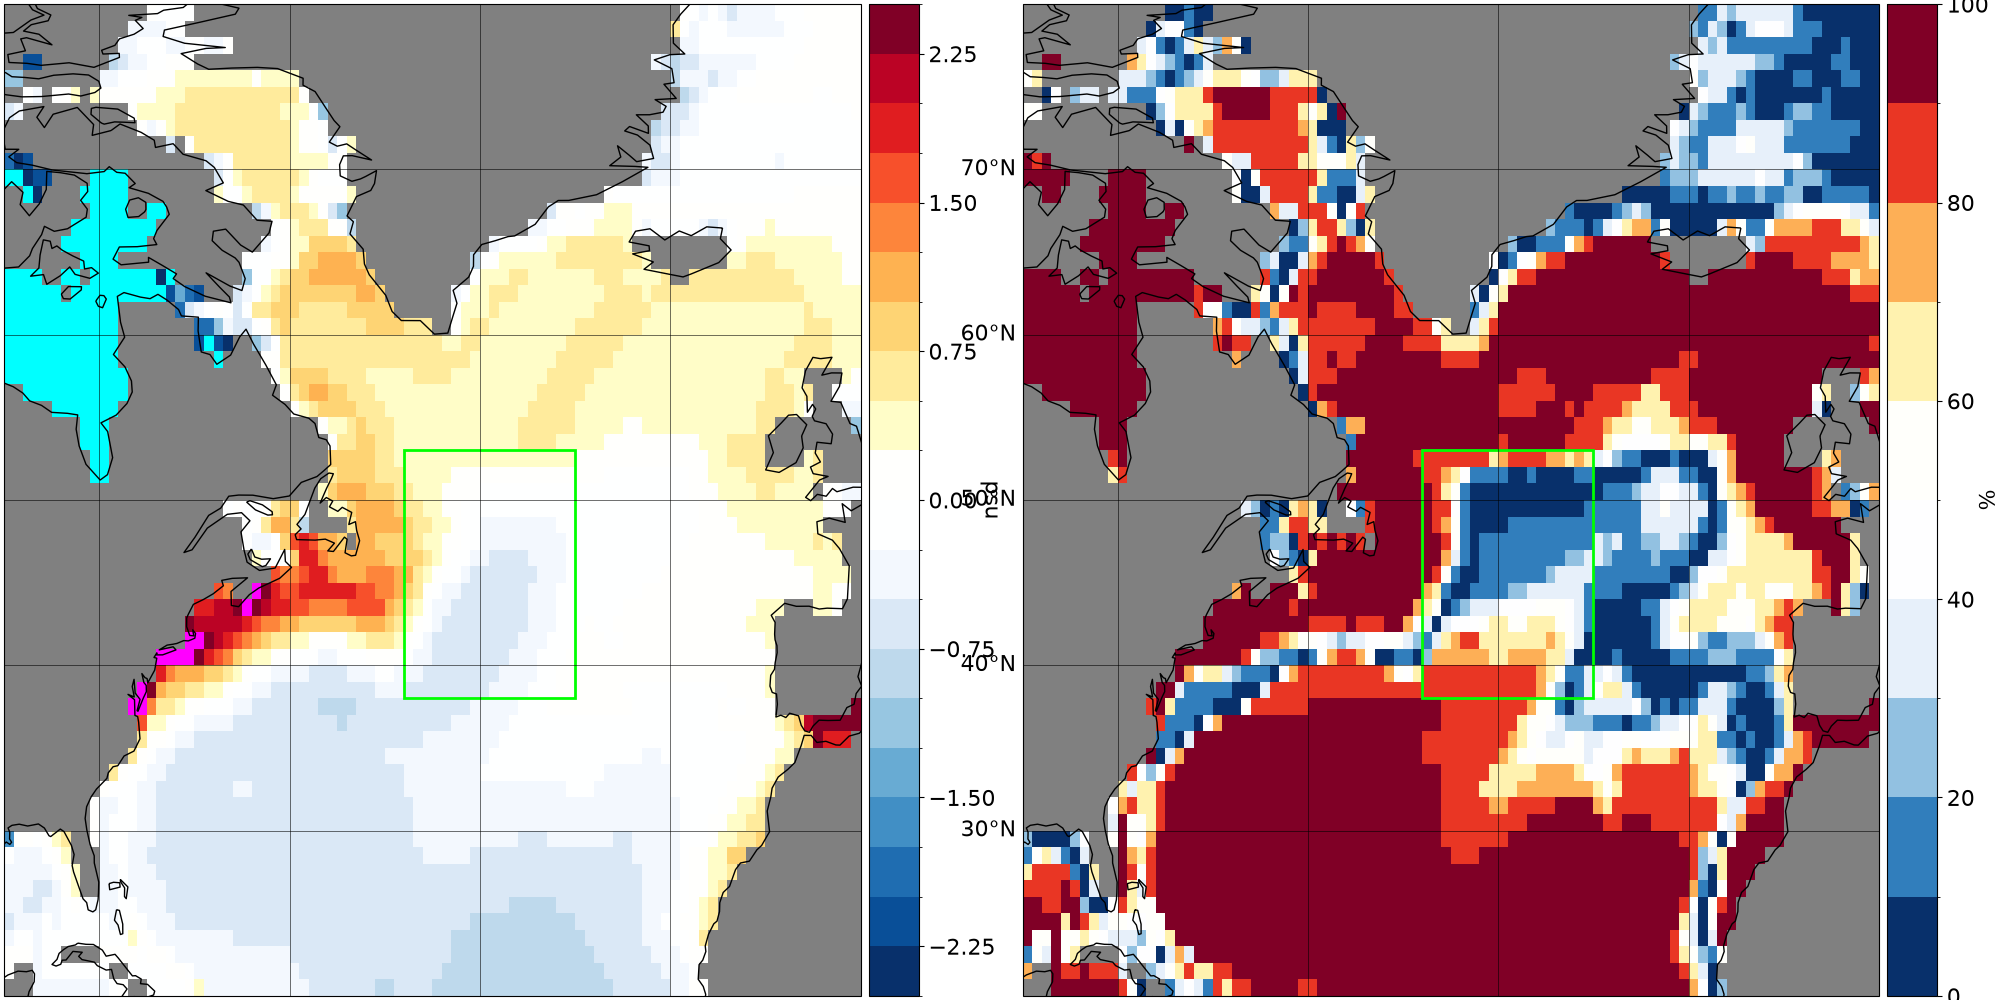

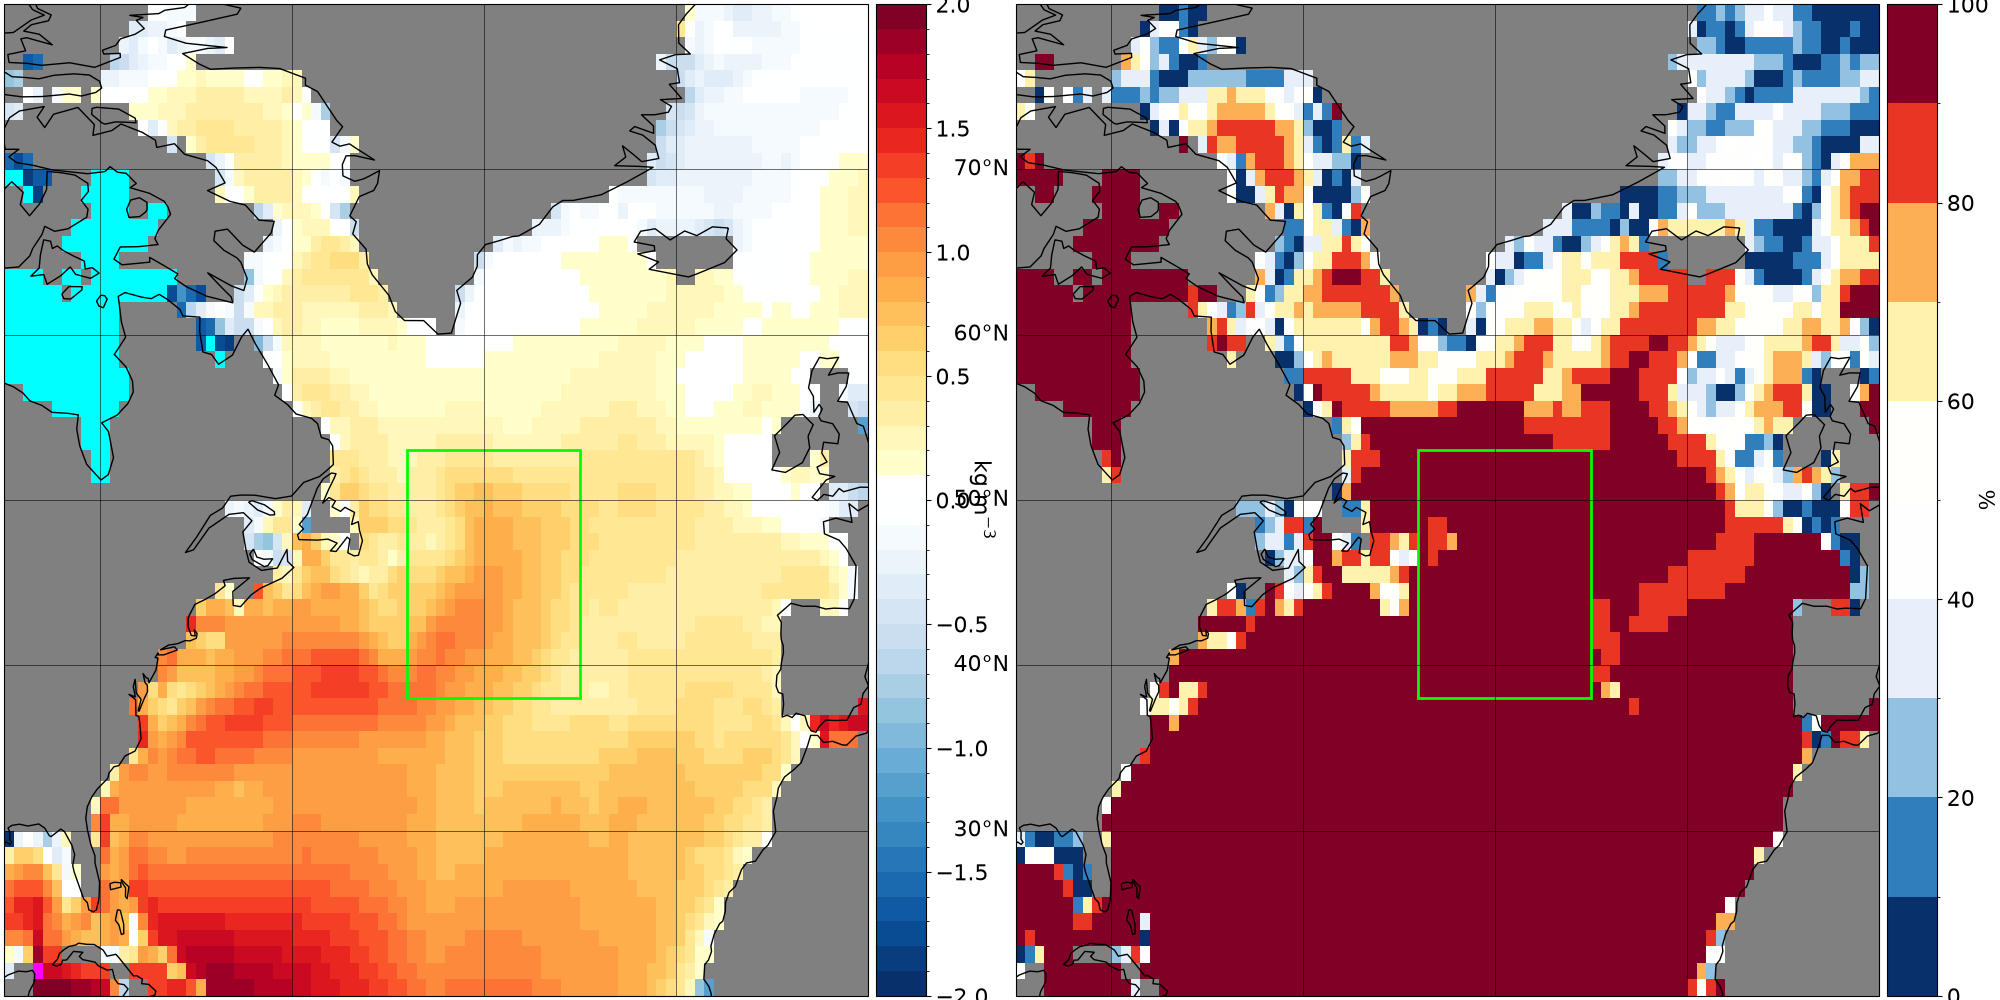

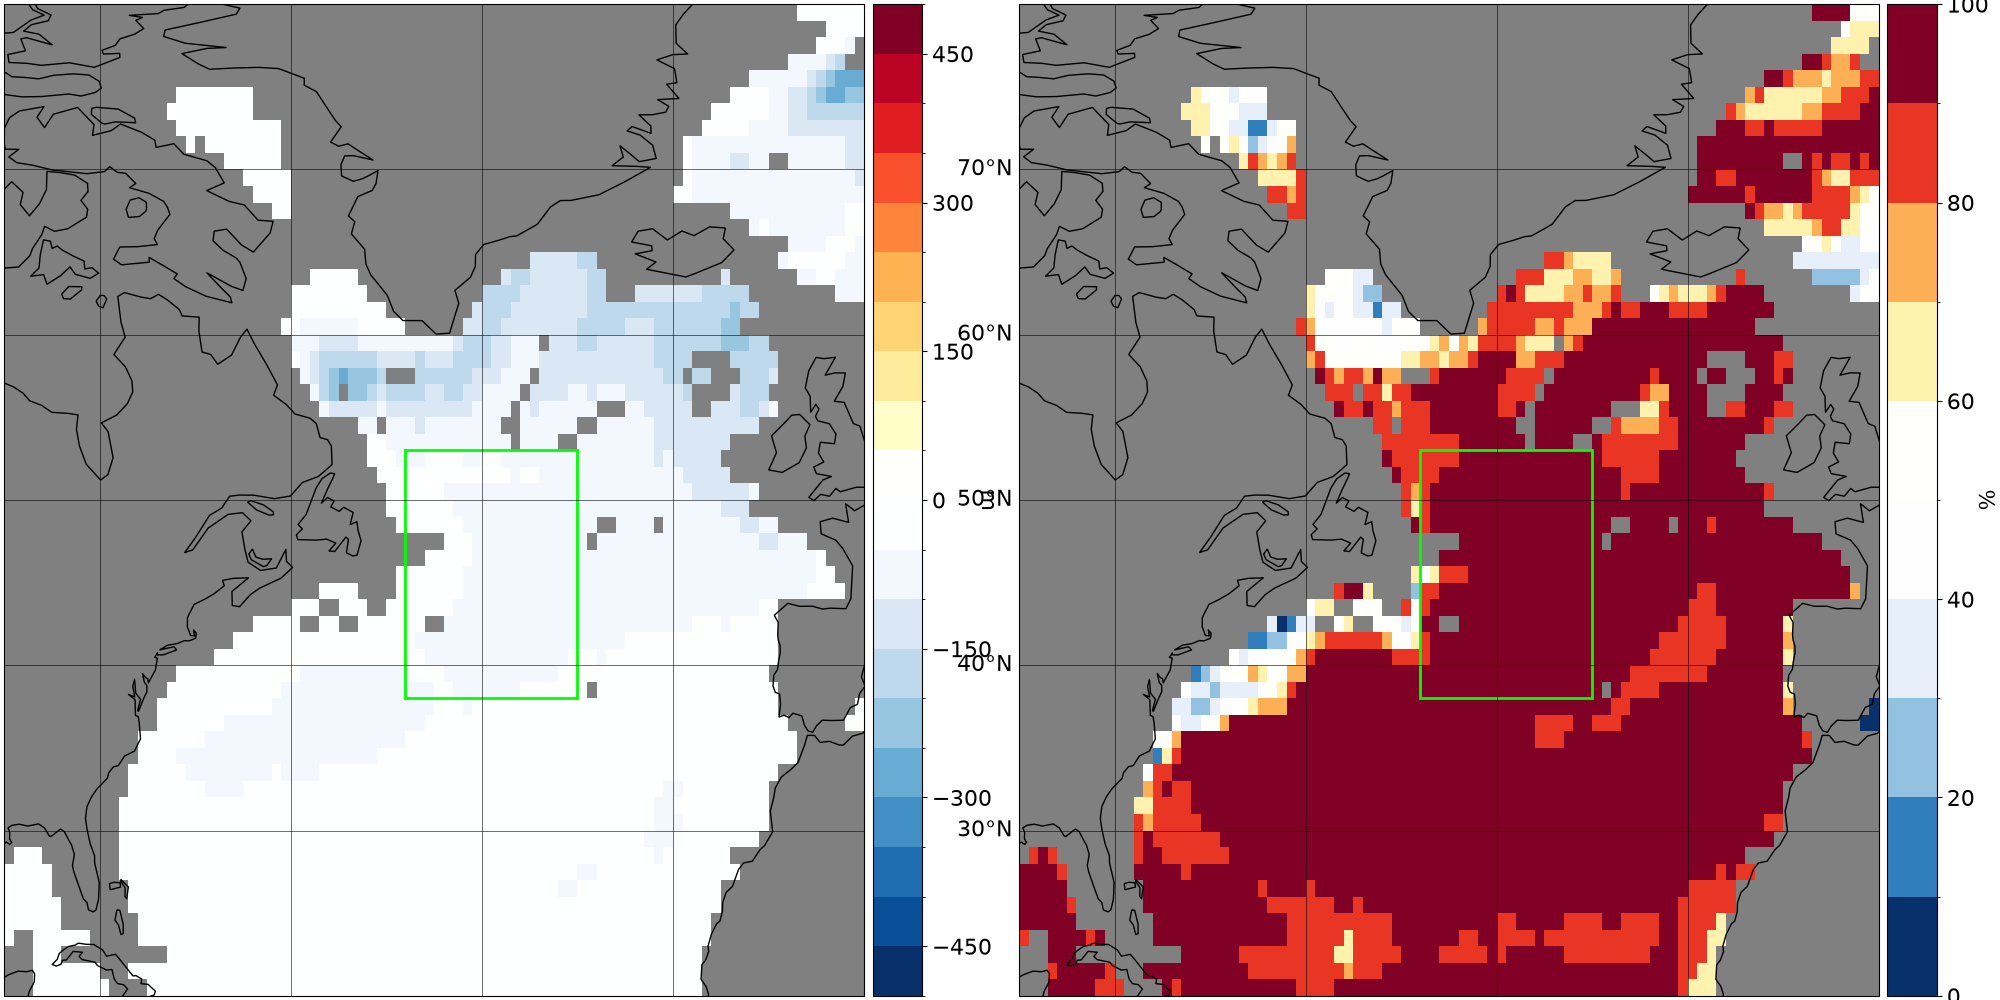

In [21]:
outmod_dir = os.path.join(os.environ['WORK_DIR'], 'model')
Path(outmod_dir).mkdir(parents=True, exist_ok=True)

region = opts['plot_region']
focus  = opts['focus_region']
month  = opts['plot_month']

ds_t200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'thetao_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=False, savedir=outmod_dir)
ds_s200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'so_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=False, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'sigma0_zavg',
                                 region=region, focus_region=focus, month=month,
                                 save=False, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'mld',
                                 region=region, focus_region=focus, month=month,
                                 save=False, savedir=outmod_dir)

### Scatter plot of θ vs S biases

Compact summary of where θ and S biases are large together.

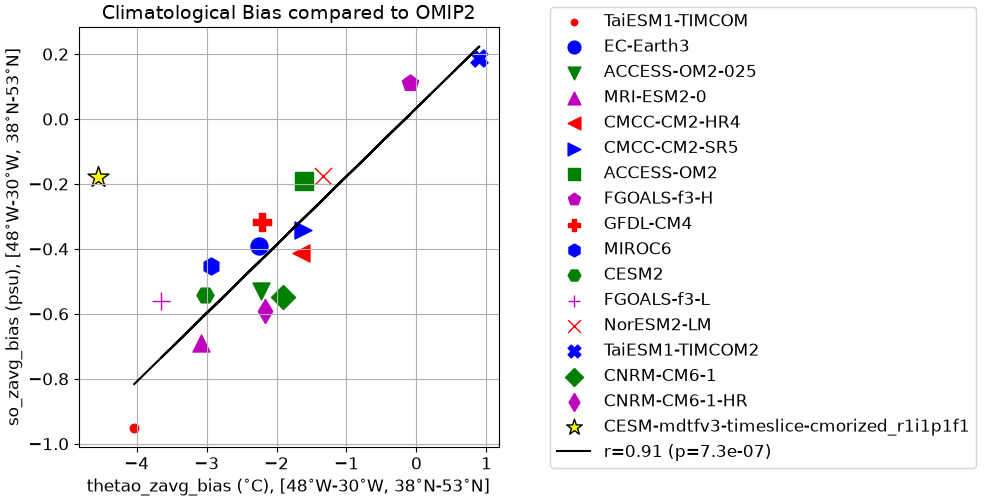

In [22]:
POD_utils.ScatterPlot_Error(
    ds_t200, 'thetao_zavg_bias',
    ds_s200, 'so_zavg_bias',
    model_name,
    save=False, savedir=outmod_dir,
)

### WMT lines vs OMIP benchmarks (by region)

Compare modeled surface-forced WMT against observation-based decomposed benchmarks (`obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc`).

WMT benchmark vars: ['heat', 'wmt', 'freshwater']


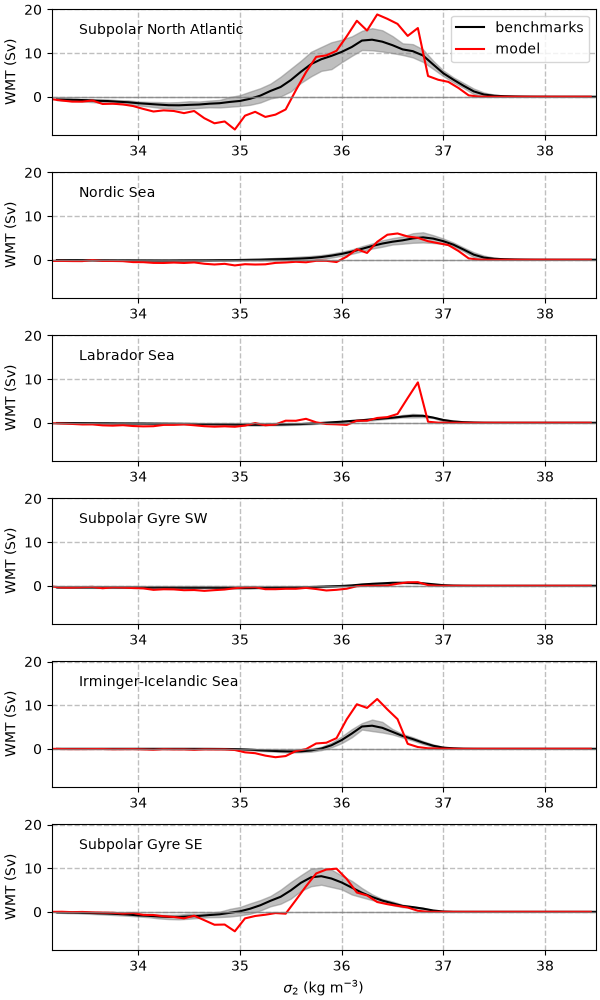

In [23]:
ds_wmt_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc')
)
print('WMT benchmark vars:', list(ds_wmt_benchmarks.data_vars))

POD_utils.wmt_plot_byregion(
    ds_wmt_benchmarks, ds_wmt_lines, sigma_classes,
    save=False, savedir=outmod_dir,
)

### Density-flux maps at specified σ₂ classes

Maps of surface density flux into each water-mass class compared to observation-based decomposed benchmarks (`obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc`).

density-flux benchmark vars: ['heat', 'salt', 'wmt', 'wmt_freq']
correcting lon for dateline


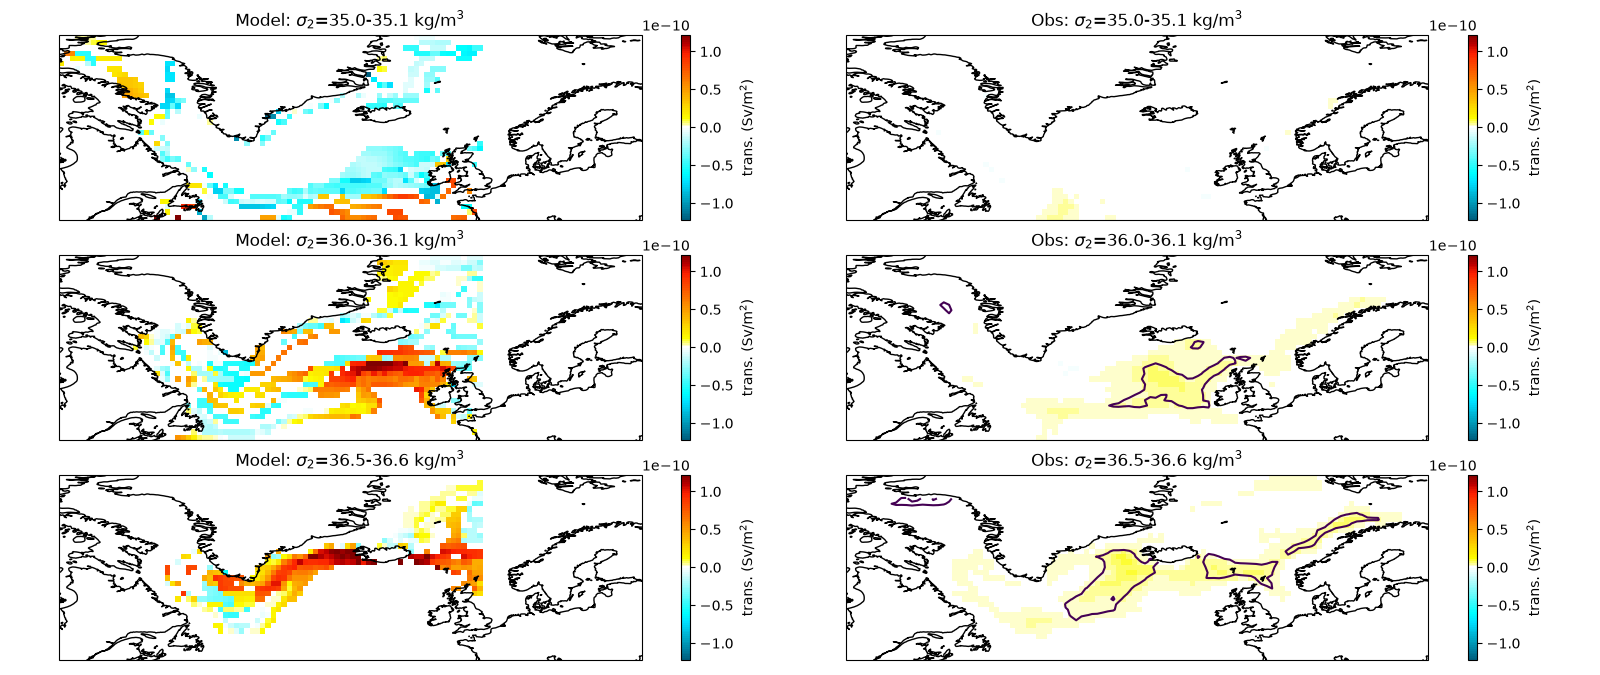

In [24]:
ds_dflux_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc')
)
print('density-flux benchmark vars:', list(ds_dflux_benchmarks.data_vars))

POD_utils.wmt_plot_maps(
    ds_dflux_benchmarks, ds_wmt_maps,
    ['time', 'x', 'y'],
    sigma_classes,
    save=False, savedir=outmod_dir,
)

### Atlantic AMOC streamfunction (σ₂ space)

Time-mean of Atlantic basin MOC (`region=1`, set by `basinmask` in `POD_utils.calculate_moc`) plotted as lat × σ₂. Positive (red) shows northward upper-cell flow; negative (blue) shows the southward deep cell. The typical CESM2 AMOC pattern is a positive cell at σ₂ < ~36.5 kg/m³ and a return cell below.

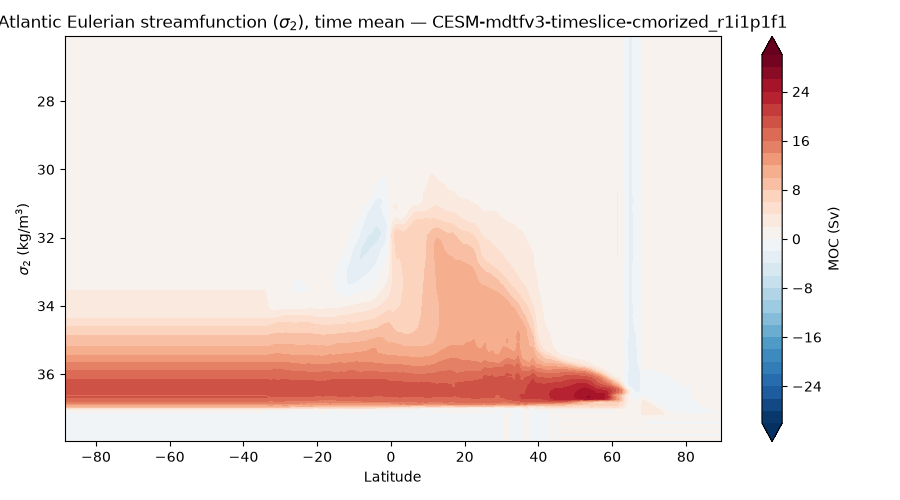

In [25]:
# Atlantic AMOC streamfunction in sigma2 (time mean).
# Plotted by POD_utils.plot_amoc_sigma2 (diagnostics printed when verbose).
_ = POD_utils.plot_amoc_sigma2(ds_moc, model_name,
                               save=False, savedir=outmod_dir)

### WMT + AMOC at 45°N (compensation diagnostic)

Three curves as functions of σ₂ for the Subpolar North Atlantic:

- **Obs WMT** mean across 8 benchmarks (black line) with the min/max spread shaded
- **Model WMT** integrated over the full SPNA (red line)
- **Model AMOC at 45°N** (blue line, time mean)

In steady state, mass conservation implies the AMOC streamfunction at 45°N approximately balances the surface-forced WMT integrated north of 45°N. Departures suggest model deficiencies in surface forcing, mixed-layer dynamics, or interior mixing.

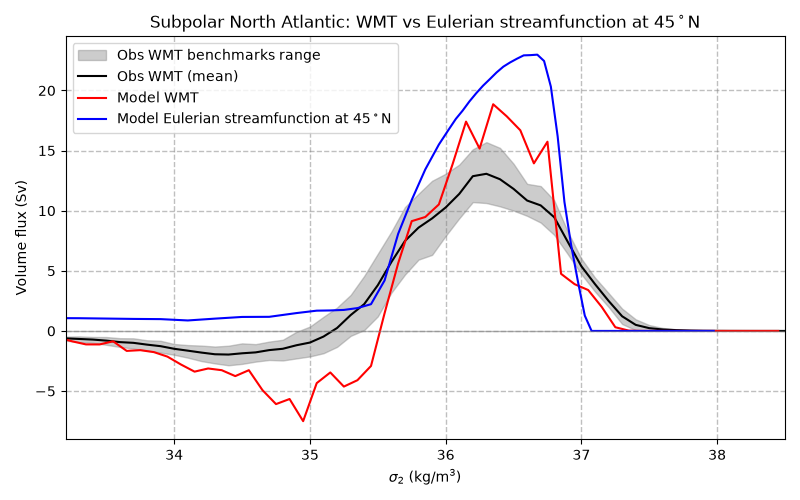

In [26]:
# WMT + AMOC at 45N compensation diagnostic
POD_utils.wmt_amoc_plot(
    ds_wmt_benchmarks, ds_wmt_lines, ds_moc,
    lat_target=45,
    region_name='Subpolar North Atlantic',
    save=False, savedir=outmod_dir,
)